# 6. Marketing wants the sale again for more of the base: who got it, what else changed, and what would settle it at Diwali?

**Week 1, Thursday. Chapter 6 of 6, the afternoon.** The morning's note told Meera that the
Retail-Plus fall is borderline and worth watching, that Student's 40 percent is not yet worth
budget, and that the monsoon sale should not be repeated as designed: its 6.1 percent blended lift
came from who got the sale, and inside each segment the customers who got it spent 3 percent less.
Marketing has replied with a bigger ask.

> **The client asks.** "Diwali is five weeks away. I want the monsoon sale again, and I want it for
> more of the base."
>
> The marketing lead, Kalpa Retail, answering the morning's note

**Who needs the answer.** Meera signs the Diwali plan, and Marketing will defend its campaign on
Monday. A sale widened on a jump that belongs to the month multiplies the margin it gives away.

**The questions on the way.**

1. Which of four ways to ask "did the sale cause it?" can the files answer?
2. Who got the monsoon sale?
3. Does August against July show the sale worked?
4. What else changed in August?
5. How would a hold-back at Diwali be designed and priced?
6. Does the month-share test, run on Q1's months with no sale, find gaps as large as August's?

**The metric at stake.** Revenue from the targeted segment in the sale month, and the question
under it: what would these customers have spent without the sale? A sale at 15 percent off either
makes money or gives margin to customers who would have bought anyway.

**Who else faces it.** eBay stopped buying search ads on its own brand name in a controlled test
and found that almost all of the lost clicks arrived through ordinary search results instead; the
researchers reported that those ads had no measurable short-term benefit, and that the returns a
controlled test showed were a fraction of what the usual readings had credited (Blake, Nosko and
Tadelis, NBER working paper 20171, checked 30 September 2026).

Chapter 4 split the blend by segment on the campaign platform's August list, and chapter 5 wrote the
note. The platform's list holds 160 customers under its own ids, records who received the sale
whatever it was aimed at, and cannot be matched to Finance's order file, so this chapter reads each
file for what it can answer: the platform's list for who got the sale and for sizing the Diwali
hold-back, and Finance's order file for what the months did. It adds `month_delivered` and
`month_orders`.

**Setup.** The whole toolkit, plus the two month helpers.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import itertools
import random
import statistics

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, members always in the same order."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def flip_gaps(q1, q2, times, seed):
    """The same members measured twice: a coin per member decides which of its two quarters is Q1."""
    random.seed(seed)                              # the same coins on every laptop
    diffs = [a - b for a, b in zip(q1, q2)]        # each member's own Q1 less Q2
    gaps = []
    for _ in range(times):
        flipped = [d if random.random() < 0.5 else -d for d in diffs]   # heads keeps, tails swaps
        gaps.append(mean(flipped))
    return gaps


def shuffle_gaps(q1, q2, times, seed):
    """Two groups of different customers: deal every value to two piles at random, many times."""
    random.seed(seed)
    pool = q1 + q2                                 # all the values, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)                       # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """Counting one direction: the share of chance-only worlds with a gap at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def share_either(gaps, real):
    """Counting either direction: the share of chance-only worlds with a gap that large, up or down."""
    return sum(1 for g in gaps if abs(g) >= abs(real)) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """The same members twice: redraw the members' own Q1 less Q2 differences with replacement."""
    random.seed(seed)
    diffs = [a - b for a, b in zip(q1, q2)]
    return [mean([random.choice(diffs) for _ in diffs]) for _ in range(times)]


def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


EXPOSURE = kit.load_csv("C2_W01_D04_exposure_STUDENT.csv")
CAMPAIGNS = kit.load_csv("C2_W01_D04_campaigns_STUDENT.csv")


def spend(rows):
    """August spend per customer across a list of exposure rows."""
    return mean([int(r["august_revenue"]) for r in rows])


def group(flag, segment=None):
    """The exposure rows for one group, exposed "yes" or "no", optionally inside one segment."""
    return [r for r in EXPOSURE if r["exposed"] == flag and (segment is None or r["segment"] == segment)]


def month_delivered(segment, month):
    """A segment's delivered revenue in one calendar month, month as "2026-08"."""
    return sum(int(o["amount"]) for o in ORDERS if o["segment"] == segment
               and o["order_date"][:7] == month and o["status"] == "delivered")


def month_orders(segment, month):
    return [o for o in ORDERS if o["segment"] == segment and o["order_date"][:7] == month
            and o["status"] == "delivered"]

MONTHS = ["2026-04", "2026-05", "2026-06", "2026-07", "2026-08", "2026-09"]
print("orders by month ready for", len(MONTHS), "months; the sale ran", CAMPAIGNS[0]["starts"], "to", CAMPAIGNS[0]["ends"])

orders by month ready for 6 months; the sale ran 2026-08-05 to 2026-08-19


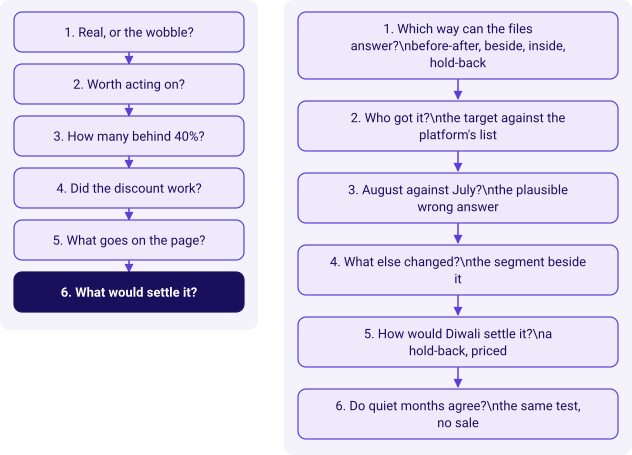

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the wobble?', 'Worth acting on?', 'How many behind 40%?', 'Did the discount work?', 'What goes on the page?', 'What would settle it?'], lit=5, show=False),
    kit.vflow(['1. Which way can the files answer?\\nbefore-after, beside, inside, hold-back', "2. Who got it?\\nthe target against the platform's list", '3. August against July?\\nthe plausible wrong answer', '4. What else changed?\\nthe segment beside it', '5. How would Diwali settle it?\\na hold-back, priced', '6. Do quiet months agree?\\nthe same test, no sale'], show=False),
)

## 1. Which of four ways to ask "did the sale cause it?" can the files answer?

Four ways a team could answer "did the sale cause the lift?". They stand on different files and
take different things on trust.

| Option | What it compares | What it assumes |
|---|---|---|
| A. Before and after | The targeted segment in August against July, in Finance's order file | Nothing else changed between the months |
| B. The change beside the change | The targeted segment's move against an untargeted segment's move over the same months | Both segments would have moved alike without the sale |
| C. Inside each segment | Customers who got it against customers who did not, in the same month, on the platform's list (chapter 4) | Who got it inside a segment was as good as random |
| D. A random hold-back | A coin decides, before the sale, which customers on the platform's list do not get it | Nothing, which is why it costs a campaign cycle |

Option,What it stands on,What it risks
A. Before and after,Finance's file: 13 delivered orders,"the season, the tier's own drift"
B. Beside an untargeted segment,Finance's file: 31 delivered orders,that the two segments move alike
C. Inside each segment,the platform's list: 160 customers,who got it was chosen by a rule
D. Random hold-back at Diwali,the platform's list: a fifth of its 70 Retail-Plus customers,"about Rs 4,200 forgone if Marketing's 6 percent were real"


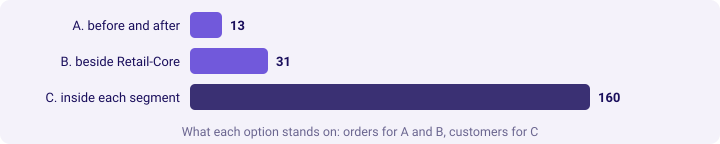

In [3]:
plus_jul, plus_aug = month_orders("Retail-Plus", "2026-07"), month_orders("Retail-Plus", "2026-08")
core_jul, core_aug = month_orders("Retail-Core", "2026-07"), month_orders("Retail-Core", "2026-08")
rp_listed = len(group("yes", "Retail-Plus")) + len(group("no", "Retail-Plus"))
held_back = rp_listed // 5
forgone = round(held_back * spend(group("no", "Retail-Plus")) * 0.06)
rows = [
    ("A. Before and after", f"Finance's file: {len(plus_jul) + len(plus_aug)} delivered orders", "the season, the tier's own drift"),
    ("B. Beside an untargeted segment", f"Finance's file: {len(plus_jul) + len(plus_aug) + len(core_jul) + len(core_aug)} delivered orders", "that the two segments move alike"),
    ("C. Inside each segment", f"the platform's list: {len(EXPOSURE)} customers", "who got it was chosen by a rule"),
    ("D. Random hold-back at Diwali", f"the platform's list: a fifth of its {rp_listed} Retail-Plus customers", f"about {kit.rupees(forgone)} forgone if Marketing's 6 percent were real"),
]
kit.table(["Option", "What it stands on", "What it risks"], rows, caption="The options sized on Kalpa's files")
kit.bars([("A. before and after", len(plus_jul) + len(plus_aug)),
          ("B. beside Retail-Core", len(plus_jul) + len(plus_aug) + len(core_jul) + len(core_aug)),
          ("C. inside each segment", len(EXPOSURE))], lit=[2],
         title="What each option stands on: orders for A and B, customers for C")
kit.check("before and after stands on fewer than thirty orders", len(plus_jul) + len(plus_aug) < 30)

**The best-fit call: D for Diwali, with C as today's best evidence.** A and B stand on a handful of
orders a month, and chapter 3 already said what a handful is worth. C is the fairest comparison the
files hold, and it still assumes who got the sale was as good as random inside each segment. D is
the only option where a coin decides, and its cost is small: if Marketing's 6 percent were real,
holding back a fifth of the platform's Retail-Plus customers forgoes a few thousand rupees. **The
fact that would change the call.** A campaign so large, or a hold-back so politically hard, that
the forgone lift runs into lakhs: then B, on a longer run of months, becomes the working answer with
its caveat said aloud.

## 2. Who got the monsoon sale?

The campaigns table says whom the sale was aimed at, which is the plan; the platform's list records
who received it, whatever it was aimed at, so where the two disagree the list is the one to trust for
who got the sale.

**Predict before you run.** Of the customers who got the monsoon sale, the share who are
Retail-Plus members is: a) all of them, since it targeted Retail-Plus; b) about half; c) about a
tenth; d) none.

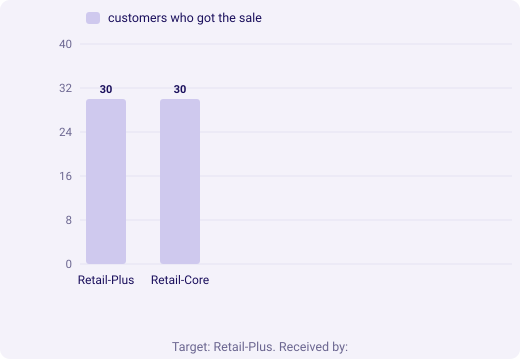

target Retail-Plus; received by {'Retail-Plus': 30, 'Retail-Core': 30}


In [4]:
got = {s: len(group("yes", s)) for s in ["Retail-Plus", "Retail-Core"]}
kit.columns(list(got), [("customers who got the sale", list(got.values()))], width=520,
            title=f"Target: {CAMPAIGNS[0]['target_segment']}. Received by:")
print(f"target {CAMPAIGNS[0]['target_segment']}; received by {got}")
kit.check("the sale reached customers outside its target segment", got["Retail-Core"] > 0, f"{got}")
kit.check("the platform's list covers both segments' customers", sum(got.values()) == len(group("yes")))

**What happened.** The answer is b. The sale was aimed at Retail-Plus and half of the customers who
got it were Retail-Core. Whatever chose them was a rule, and a rule can pick the customers who were
going to buy anyway. That is the first of the three questions, and it is already an answer: the
groups were chosen.

## 3. Does August against July show the sale worked?

**The plausible wrong answer.** A hurried readout opens Finance's order file and compares
Retail-Plus in the sale month with the month before.

In [5]:
rp_jul, rp_aug = month_delivered("Retail-Plus", "2026-07"), month_delivered("Retail-Plus", "2026-08")
before_after = rp_aug / rp_jul - 1
draft = (f"Retail-Plus delivered {kit.rupees(rp_aug)} in August against {kit.rupees(rp_jul)} in July, "
         f"up {before_after:.0%}: the monsoon sale worked, so run it for more of the base at Diwali.")
print(draft)

Retail-Plus delivered Rs 25,060 in August against Rs 9,280 in July, up 170%: the monsoon sale worked, so run it for more of the base at Diwali.


**Why it is wrong.** A before-and-after number credits the sale with everything else that happened
between July and August, and it stands on a handful of orders. If the draft wins, Diwali's sale is
widened on a jump that may belong to the month. **The check** asks what else changed: put the
untargeted segment beside it over the same months, and count what each month stands on.

## 4. What else changed in August?

**Predict before you run.** Between July and August, Retail-Core's delivered revenue: a) fell, as
the sale pulled buyers to Retail-Plus; b) stayed flat; c) rose by a large share as well; d) cannot
be compared.

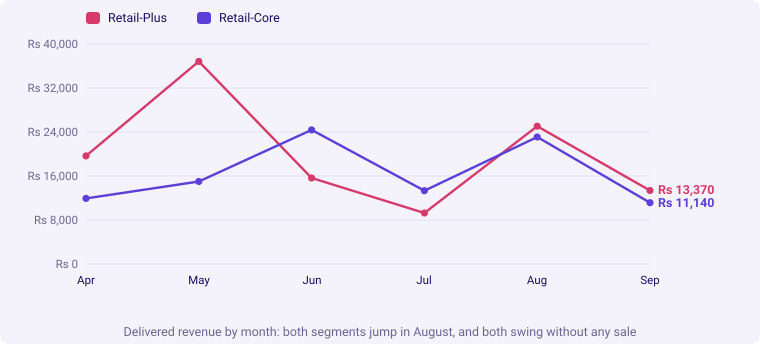

Segment,July,August,Change,"Delivered orders, July / August"
Retail-Plus,"Rs 9,280","Rs 25,060",+170%,4 / 9
Retail-Core,"Rs 13,320","Rs 23,090",+73%,6 / 12


Retail-Plus May to June, no sale running: -58%


In [6]:
rp = [month_delivered("Retail-Plus", m) for m in MONTHS]
core = [month_delivered("Retail-Core", m) for m in MONTHS]
kit.line(["Apr", "May", "Jun", "Jul", "Aug", "Sep"], [("Retail-Plus", rp, "bad"), ("Retail-Core", core, "plain")],
         fmt=kit.rupees, title="Delivered revenue by month: both segments jump in August, and both swing without any sale")
core_jump = core[4] / core[3] - 1
may_june = rp[2] / rp[1] - 1
kit.table(["Segment", "July", "August", "Change", "Delivered orders, July / August"],
          [("Retail-Plus", kit.rupees(rp[3]), kit.rupees(rp[4]), f"{before_after:+.0%}", f"{len(plus_jul)} / {len(plus_aug)}"),
           ("Retail-Core", kit.rupees(core[3]), kit.rupees(core[4]), f"{core_jump:+.0%}", f"{len(core_jul)} / {len(core_aug)}")],
          caption="July against August, with the orders behind each month")
print(f"Retail-Plus May to June, no sale running: {may_june:+.0%}")
kit.check("the untargeted segment also jumped in August", core_jump > 0.5, f"{core_jump:+.0%}")
kit.check("Retail-Plus swung by more than half between two months with no sale", abs(may_june) > 0.5, f"{may_june:+.0%}")
kit.check("July's Retail-Plus figure stands on fewer than ten orders", len(plus_jul) < 10, f"{len(plus_jul)}")

**What happened.** The answer is c. Retail-Core rose 73 percent from July to August although the
sale was aimed elsewhere, and Retail-Plus fell 58 percent from May to June with no sale at all. A
month's revenue on a few orders swings by half on its own, and August was a big month for both
segments.

**The fix.** Compare like with like in time as well: take August's share of each segment's
quarter, then ask how often chance alone makes a gap that large between the two segments, dealing
the segment labels at random across both segments' delivered Q2 orders. These are different
customers in each segment, so the labels are shuffled, as chapter 1's options table said they would
be. As in chapter 1, both directions are reported, since neither direction was fixed before August
was seen: a gap that large either way, and a Retail-Plus share that much higher, which is the
direction Marketing's claim points.

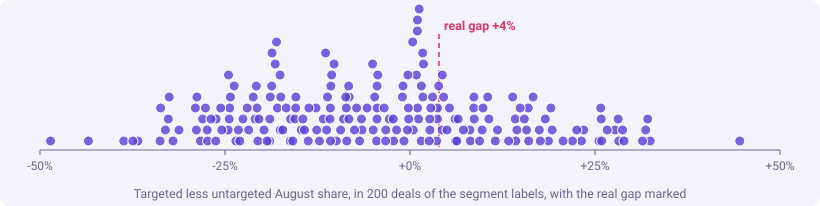

August's share of Q2: Retail-Plus 52.5%, Retail-Core 48.6%, a gap of 4.0 points; shuffled labels make a gap that large either way in 0.82 of deals, and a Retail-Plus share that much higher in 0.40


In [7]:
def month_share_test(months, target, times=5000, seed=2026):
    """The target month's share of each segment's quarter, and how often shuffled segment labels make that gap."""
    plus = [month_delivered("Retail-Plus", m) for m in months]
    other = [month_delivered("Retail-Core", m) for m in months]
    at = months.index(target)
    gap = plus[at] / sum(plus) - other[at] / sum(other)
    rows = ([(int(o["amount"]), o["order_date"][:7]) for m in months for o in month_orders("Retail-Plus", m)]
            + [(int(o["amount"]), o["order_date"][:7]) for m in months for o in month_orders("Retail-Core", m)])
    n_plus = sum(len(month_orders("Retail-Plus", m)) for m in months)

    def share(part):
        return sum(a for a, m in part if m == target) / sum(a for a, _ in part)

    random.seed(seed)
    chance = []
    for _ in range(times):
        random.shuffle(rows)                      # deal the segment labels at random
        chance.append(share(rows[:n_plus]) - share(rows[n_plus:]))
    either = sum(1 for c in chance if abs(c) >= abs(gap)) / times
    up = sum(1 for c in chance if c >= gap) / times
    return plus[at] / sum(plus), other[at] / sum(other), gap, either, up, chance


aug_share_rp, aug_share_core, real_gap, chance_either, chance_up, chance = month_share_test(MONTHS[3:], "2026-08")
kit.strip(chance[:200], markers=[("real gap", real_gap, "bad")], lo=-0.5, hi=0.5, fmt=lambda v: f"{v:+.0%}",
          title="Targeted less untargeted August share, in 200 deals of the segment labels, with the real gap marked")
print(f"August's share of Q2: Retail-Plus {aug_share_rp:.1%}, Retail-Core {aug_share_core:.1%}, a gap of "
      f"{100 * real_gap:.1f} points; shuffled labels make a gap that large either way in {chance_either:.2f} of deals, "
      f"and a Retail-Plus share that much higher in {chance_up:.2f}")
kit.check("August's share is within a few points for the targeted and the untargeted segment",
          abs(aug_share_rp - aug_share_core) < 0.06, f"{aug_share_rp:.1%} against {aug_share_core:.1%}")
kit.check("counting either way, 4,124 of 5,000 deals make the gap (seed 2026)", round(chance_either * 5000) == 4124, f"{chance_either:.4f}")
kit.check("counting Marketing's direction only, 2,006 of 5,000 do", round(chance_up * 5000) == 2006, f"{chance_up:.4f}")

What changed: the jump of 170 percent becomes an August that took 52 percent of Retail-Plus's
quarter against 49 percent of Retail-Core's, about four points apart, and shuffling the segment
labels makes a gap that large either way in about eight deals in ten, and a gap that large in
Marketing's direction in about four in ten. The month file shows no sign of the sale beyond a busy
August for everyone. Retail-Core is also an imperfect comparison: it is the segment the sale was not
aimed at, yet section 2 showed the platform's list counting Retail-Core customers among those who got
it. If the sale lifted both segments, similar Augusts would look like this too, which is one more
reason only a coin can settle it.

## 5. How would a hold-back at Diwali be designed and priced?

The only comparison that answers "would they have bought anyway?" is one where a coin decides who
gets the sale. Decide before the sale, inside each segment of the platform's list, and agree the
measure and the window in advance.

**Predict before you run.** If Marketing's 6 percent were the true lift, holding back a random
fifth of the platform's Retail-Plus customers would forgo about: a) Rs 4,000; b) Rs 40,000; c) Rs 4
lakh; d) nothing, since held-back customers still buy.

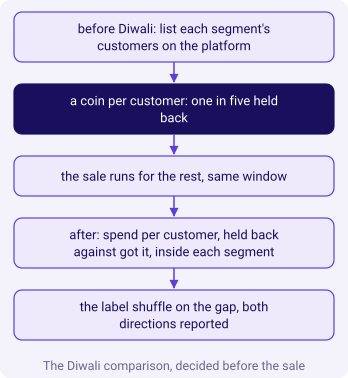

List,Retail-Plus customers,"August, per customer",What it sizes
the platform's August list,70,"Rs 5,000 spend, not exposed",the Diwali hold-back
Finance's order file,22,"Rs 1,139 delivered",the retention offer


In [8]:
kit.vflow(["before Diwali: list each segment's customers on the platform",
           "a coin per customer: one in five held back",
           "the sale runs for the rest, same window",
           "after: spend per customer, held back against got it, inside each segment",
           "the label shuffle on the gap, both directions reported"],
          lit=1, title="The Diwali comparison, decided before the sale")
finance_members = len({o["customer_id"] for o in ORDERS if o["segment"] == "Retail-Plus"})
finance_aug = month_delivered("Retail-Plus", "2026-08") / finance_members
kit.table(["List", "Retail-Plus customers", "August, per customer", "What it sizes"],
          [("the platform's August list", rp_listed, kit.rupees(spend(group("no", "Retail-Plus"))) + " spend, not exposed", "the Diwali hold-back"),
           ("Finance's order file", finance_members, kit.rupees(finance_aug) + " delivered", "the retention offer")],
          caption="Two lists, two sizes: each decision is sized on the list it acts on")
kit.stats([(f"{held_back}", "held back", f"a fifth of the platform's {rp_listed} Retail-Plus customers"),
           (kit.rupees(forgone), "forgone", "if Marketing's 6 percent were real"),
           ("0", "rupees of discount", "given to the held-back customers")])
kit.check("the hold-back forgoes under Rs 10,000 even at Marketing's own lift", forgone < 10000, kit.rupees(forgone))
kit.check("the two lists hold different numbers of Retail-Plus customers", rp_listed != finance_members,
          f"{rp_listed} against {finance_members}")

**What happened.** The answer is a. Fourteen held-back Retail-Plus customers at Rs 5,000 each and a
6 percent lift is about Rs 4,200, the cost of the hold-back, and nothing if the lift is not real.

The two lists meet head-on here. The morning priced the retention offer on "the whole tier" of 22 and
tests it on a coin-chosen half of them, and this hold-back takes 14 of 70. Both are right, because
they are different lists. The 22 are
Finance's order file, where Retail-Plus members delivered about Rs 1,139 each in August; the 70 are
the platform's list, where Retail-Plus customers who did not get the sale averaged Rs 5,000. The
lists use different ids and different measures, delivered revenue per member in Finance's file and
the platform's own average spend per customer, so neither number can check the other. Each decision
is sized on the list it acts on: the offer on Finance's members, the hold-back on the platform's
customers.

Fourteen customers are too few to measure a lift as small as 6 percent, since spend swings far more
than that from customer to customer; how many a hold-back needs is a question of power, which comes
in a later week, and the honest design holds back a random slice of every segment the sale reaches.

## 6. Does the month-share test, run on Q1's months with no sale, find gaps as large as August's?

Section 4 read August's four points against shuffled labels. A placebo checks the reading from outside
it: run the same month-share test on the three months of Q1, when no sale ran. If months with no sale
produce gaps as large as August's, or larger, then August's gap carries no sign of the sale. This
route uses a different quarter of Finance's file and shares nothing with chapter 4's split.

**Predict before you run.** Across April, May and June, the gaps between the two segments' monthly
shares will be: a) all near zero, since no sale ran; b) about as large as August's, or larger; c)
larger only in the month before a sale; d) impossible to compute without a sale.

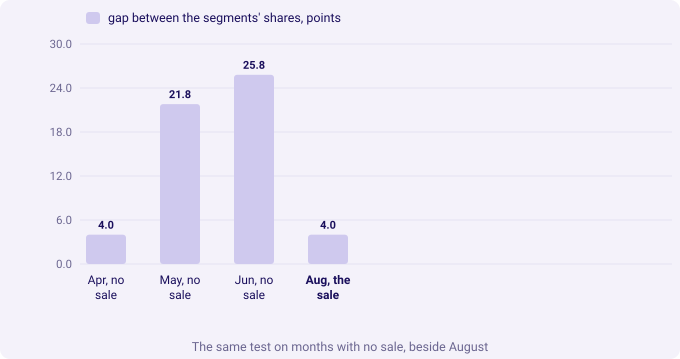

Month,Retail-Plus share,Retail-Core share,"Gap, points",Either way,Retail-Plus higher
2026-04,27.2%,23.2%,+4.0,0.764,0.386
2026-05,51.1%,29.2%,+21.8,0.150,0.078
2026-06,21.7%,47.5%,-25.8,0.066,0.963
2026-08,52.5%,48.6%,+4.0,0.825,0.401


In [9]:
placebo = {m: month_share_test(MONTHS[:3], m) for m in MONTHS[:3]}
labels = ["Apr, no sale", "May, no sale", "Jun, no sale", "Aug, the sale"]
gaps = [abs(100 * placebo[m][2]) for m in MONTHS[:3]] + [abs(100 * real_gap)]
kit.columns(labels, [("gap between the segments' shares, points", [round(g, 1) for g in gaps])], lit=[3],
            fmt=lambda v: f"{v:.1f}", width=680, title="The same test on months with no sale, beside August")
kit.table(["Month", "Retail-Plus share", "Retail-Core share", "Gap, points", "Either way", "Retail-Plus higher"],
          [(m, f"{p[0]:.1%}", f"{p[1]:.1%}", f"{100 * p[2]:+.1f}", f"{p[3]:.3f}", f"{p[4]:.3f}") for m, p in placebo.items()]
          + [("2026-08", f"{aug_share_rp:.1%}", f"{aug_share_core:.1%}", f"{100 * real_gap:+.1f}", f"{chance_either:.3f}", f"{chance_up:.3f}")],
          caption="Each month's share of its own quarter, with how often shuffled labels make that gap")
kit.check("every month of the quarter with no sale shows a gap at least as large as August's",
          all(abs(p[2]) >= abs(real_gap) for p in placebo.values()), f"{[round(100 * p[2], 1) for p in placebo.values()]}")
kit.check("the largest no-sale gap is more than five times August's", max(abs(p[2]) for p in placebo.values()) > 5 * abs(real_gap))

**What happened.** The answer is b. In the quarter with no sale, the gaps between the segments'
monthly shares run 4, 22 and 26 points, and shuffled labels make May's and June's gaps in about 15
and 7 deals in 100 counting either way. Months with no sale produce gaps as large as August's four
points and far larger, so August's gap carries no sign of the sale. Chapter 4's split, on the
platform's list, found the exposed spending 3 percent less in both segments: neither route shows
the lift Marketing claimed, and neither is a fair comparison, because nobody tossed a coin. That is
why the line to Meera stays "do not repeat it as designed" and the action is the hold-back. **When to
switch.** Use the change beside the change when months of data exist and no hold-back was run; use
the split when an exposure list exists; run the hold-back whenever the next campaign can still be
designed.

Kavya Nair, the team's senior analyst, reads every answer before it leaves the team.

> **Kavya's review.** "A rule chose who got the sale, the rest hold a different mix, and August was
> busy for everyone, while a quarter with no sale swings further. Two routes find no lift,
> and you priced the hold-back at about Rs 4,200 on the list it acts on. Take that to Marketing as an
> offer, and keep any verdict on their work out of it."

### In the interview: how would you set up Diwali so you can tell whether it worked?

**[F] Revenue rose after a discount; did the campaign work, and what would you need to know?** "Three
things: who got it, who did not, and what else changed. A before-and-after number credits the
campaign with the season. I would compare against customers who did not get it in the same window,
inside each segment, run the same test on months with no campaign to see what an ordinary month
does, and ask for a random hold-back next time, because that is the only comparison where the
customers who would have bought anyway are in both groups."

**[F] How would you set up the Diwali campaign so you can tell whether it worked?** "Before the sale,
a coin per customer inside each segment holds back about one in five. Agree the measure, the window
and the direction of the test in advance, run the sale for the rest, then compare spend per customer
inside each segment and test the gap against chance. At Marketing's own claimed lift the hold-back
costs a few thousand rupees, and the size of the hold-back is set by how small a lift we need to see,
which is a later week's question."

**[S] What is a confounder? Give an example from a campaign.** "Something that differs between the
groups and moves the outcome on its own. Here the sale went to a group with more high-spending
Retail-Plus members, and August was a big month for everyone, so both the mix and the month move
revenue whether or not the sale did anything."

**[D] Before and after, the change beside the change, the split, or a hold-back: which would you
defend to a CFO, and when would you settle for less?** "The hold-back, because only a coin removes
the customers who would have bought anyway from the comparison. I would settle for the change
beside the change on a long run of months when a hold-back is impossible, and say its assumption
aloud: that both segments would have moved alike."

### Depth: what do analysts call Retail-Plus's change less Retail-Core's, and why can it not settle whether the sale worked?

Analysts call option B a difference in differences: the targeted segment's change less the
untargeted segment's change over the same window. Below it is in rupees, beside the months that
show why it cannot settle whether the sale worked.

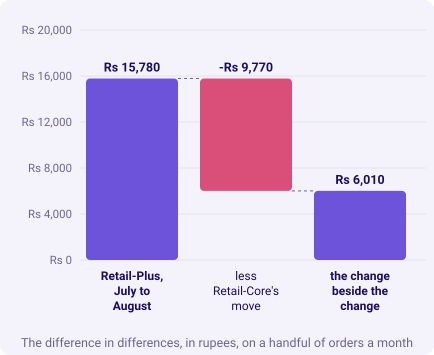

Retail-Plus moved Rs 15,780, Retail-Core Rs 9,770; difference Rs 6,010


In [10]:
did = (rp[4] - rp[3]) - (core[4] - core[3])
kit.bridge(("Retail-Plus, July to August", rp[4] - rp[3]), [("less Retail-Core's move", -(core[4] - core[3]))],
           end_label="the change beside the change", title="The difference in differences, in rupees, on a handful of orders a month")
print(f"Retail-Plus moved {kit.rupees(rp[4] - rp[3])}, Retail-Core {kit.rupees(core[4] - core[3])}; difference {kit.rupees(did)}")
kit.check("the difference rests on fewer than thirty orders in the targeted segment", len(plus_jul) + len(plus_aug) < 30)

It says Retail-Plus rose about Rs 6,000 more than Retail-Core, on 13 orders across the two months,
from a segment whose months swing by half with no sale running. The route assumes the two segments
move alike without the sale, and the months before it say they do not: from May to June Retail-Plus
fell 58 percent while Retail-Core rose 63 percent. That makes it a lead to follow up, and it points
the same way as everything else in this chapter: run the hold-back.

## So who got the sale, what else changed, and what would settle it at Diwali?

1. The split inside each segment is today's best evidence, and a random hold-back is the call for
   Diwali; a hold-back refused, or one whose forgone lift ran into lakhs, would push the team to
   months of the change beside the change.
2. The campaigns table aimed the sale at Retail-Plus, and the platform's list shows 30 Retail-Plus
   and 30 Retail-Core customers got it: a rule chose them.
3. No: Retail-Plus delivered Rs 25,060 in August against Rs 9,280 in July, up 170 percent, but
   Retail-Core rose 73 percent the same month and July stands on 4 delivered orders.
4. August was busy for everyone: it took 52.5 percent of Retail-Plus's quarter and 48.6 percent of
   Retail-Core's, a gap that shuffled labels make in 0.82 of deals either way and 0.40 in Marketing's
   direction.
5. A coin holds back one in five inside each segment before the sale: 14 of the platform's 70
   Retail-Plus customers, forgoing about Rs 4,200 at Marketing's own 6 percent, too few to see a
   lift that small.
6. Yes, and larger: Q1's months, with no sale, show gaps of 4, 22 and 26 points, so August's 4 carries no sign
   of the sale.

Nothing in the files shows a lift the sale can claim. Hold back a random fifth of each segment at
Diwali, agree the measure in advance, and compare inside each segment.

In [11]:
kit.check_summary()
print("Next: the escalated case. Everything the six chapters built, alone, on all three questions.")

Next: the escalated case. Everything the six chapters built, alone, on all three questions.
